PREPARING DATA FOR CLUSTERING
--------------------------------------------------

Dataset shape: (5278, 8)
Features used: 8
Total libraries: 5278

Scaling complete. All features normalized.

FINDING OPTIMAL NUMBER OF CLUSTERS

Method 1: Elbow Method

Method 2: Silhouette Score
k=2: Silhouette=0.6951
k=3: Silhouette=0.6086
k=4: Silhouette=0.4576
k=5: Silhouette=0.4571
k=6: Silhouette=0.3856
k=7: Silhouette=0.4399
k=8: Silhouette=0.3608


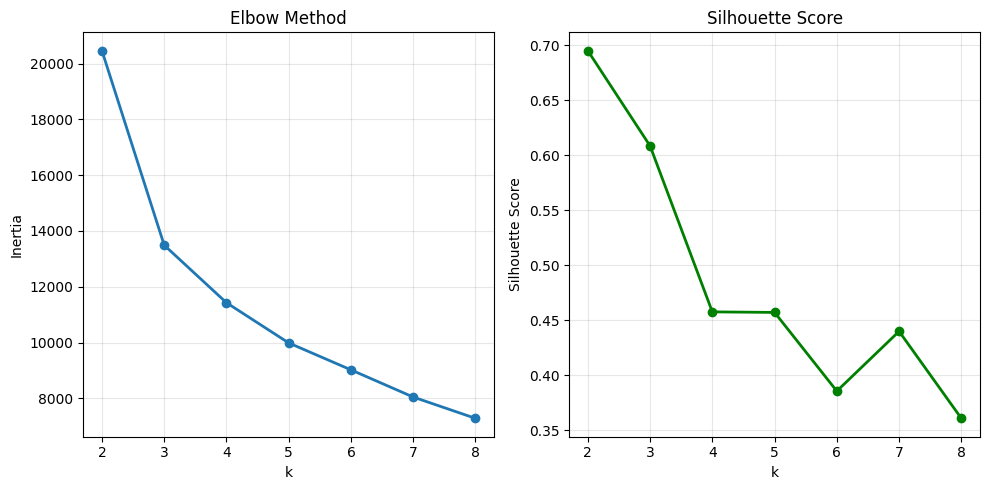


✓ BEST k = 2 (Silhouette=0.6951)

TRAINING K-MEANS WITH k=2

Cluster Counts:
Cluster
0    4610
1     668
Name: count, dtype: int64

PCA Variance Explained: 88.64%


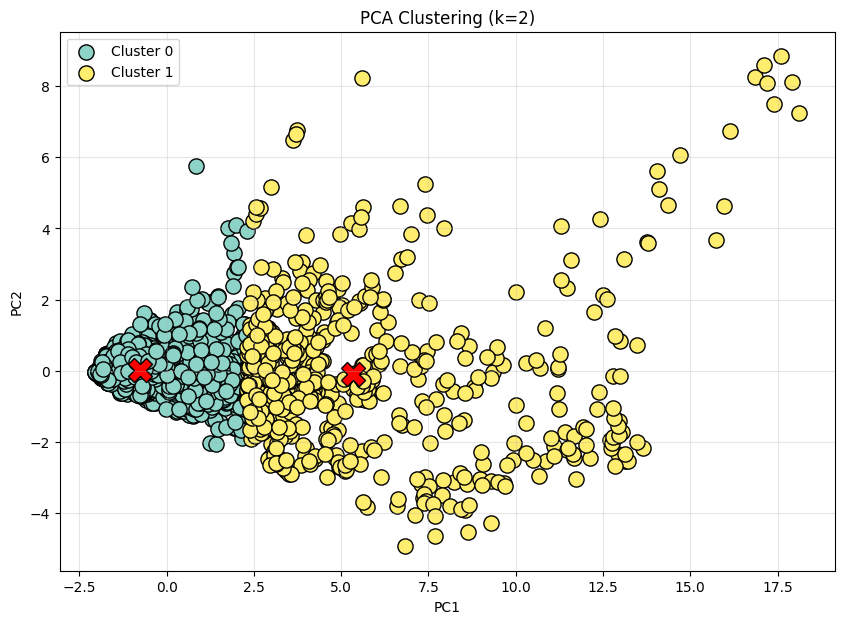


Silhouette Score: 0.6951
Davies-Bouldin Index: 0.7965

CLUSTERING COMPLETE!


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.decomposition import PCA
import pickle

# Load Data
df = pd.read_csv("cleaned_data.csv")

# =============================================================================
# PART 1: PREPARE DATA FOR CLUSTERING
# =============================================================================
print("PREPARING DATA FOR CLUSTERING")
print("-" * 50)

# FIXED FEATURE LIST — no Total Circulation, no Operating Expenditures
cluster_features = [
    'Population of Service Area',
    'Total Library Visits',
    'Total Programs (Synchronous + Prerecorded)',
    'Total Program Attendance & Views',
    'Total Collection',
    'Wages & Salaries Expenditures',
    'Library Materials Expenditures',
    'Town Tax Appropriation for Library'
]

X = df[cluster_features]
print(f"\nDataset shape: {X.shape}")
print(f"Features used: {len(cluster_features)}")
print(f"Total libraries: {len(df)}")

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nScaling complete. All features normalized.\n")

# =============================================================================
# PART 2: FIND OPTIMAL NUMBER OF CLUSTERS
# =============================================================================
print("="*50)
print("FINDING OPTIMAL NUMBER OF CLUSTERS")
print("="*50)

# Elbow Method
print("\nMethod 1: Elbow Method")
inertias = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(K_range, inertias, marker='o', linewidth=2)
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.grid(alpha=0.3)

# Silhouette Score
print("\nMethod 2: Silhouette Score")
sil_scores = []
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    sil_scores.append(sil)
    print(f"k={k}: Silhouette={sil:.4f}")

plt.subplot(1, 2, 2)
plt.plot(K_range, sil_scores, marker='o', linewidth=2, color='green')
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

best_k = K_range[np.argmax(sil_scores)]
best_silhouette = max(sil_scores)

print(f"\n✓ BEST k = {best_k} (Silhouette={best_silhouette:.4f})\n")

# =============================================================================
# PART 3: TRAIN FINAL K-MEANS MODEL
# =============================================================================
print("="*50)
print(f"TRAINING K-MEANS WITH k={best_k}")
print("="*50)

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

df["Cluster"] = cluster_labels

cluster_counts = df["Cluster"].value_counts().sort_index()

print("\nCluster Counts:")
print(cluster_counts)

# =============================================================================
# PART 4: PCA VISUALIZATION
# =============================================================================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df["PC1"] = X_pca[:, 0]
df["PC2"] = X_pca[:, 1]

print(f"\nPCA Variance Explained: {sum(pca.explained_variance_ratio_):.2%}")

plt.figure(figsize=(10, 7))
colors = plt.cm.Set3(np.linspace(0, 1, best_k))

for c in range(best_k):
    subset = df[df["Cluster"] == c]
    plt.scatter(subset["PC1"], subset["PC2"], c=[colors[c]], s=120, edgecolors='black', label=f"Cluster {c}")

centers_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(centers_pca[:, 0], centers_pca[:, 1], s=300, c="red", marker="X", edgecolors="black")

plt.title(f"PCA Clustering (k={best_k})")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# =============================================================================
# QUALITY METRICS
# =============================================================================
db_score = davies_bouldin_score(X_scaled, cluster_labels)

print(f"\nSilhouette Score: {best_silhouette:.4f}")
print(f"Davies-Bouldin Index: {db_score:.4f}")

# =============================================================================
# SAVE MODELS
# =============================================================================
pickle.dump(kmeans, open("models/kmeans_model.pkl", "wb"))
pickle.dump(scaler, open("models/scaler_cluster.pkl", "wb"))
pickle.dump(pca, open("models/pca_model.pkl", "wb"))

print("\nCLUSTERING COMPLETE!")
print("="*50)
